In [4]:
from scipy.stats import spearmanr
from scipy.stats import pearsonr
import numpy as np
import os
from sklearn.linear_model import LinearRegression
import copy
import pandas as pd
from funciones import J_univariante, J_bivariante, interpolador, interpolador_constante, interpolador_estocastico, derivada_index, remove_consecutive_duplicates, brownian_bridge, generar_uniforme_centrada
from scipy.interpolate import PchipInterpolator


In [5]:
#dataframe datos de compositores 
def extraer_dataset_musica():

    datos_composers = {}
    carpeta = r'data\Sequences\labels'
    archivos_en_carpeta = os.listdir(carpeta)
    index0 = 0
    indice = 0

    for archivo in archivos_en_carpeta:
        ruta_completa = os.path.join(carpeta, archivo)
        serie = pd.read_csv(ruta_completa, header = None)
        composer = archivo.split('-')[1].capitalize() # nombre compositor
        datos_composers[composer] = {} #genero bibio para composer
        datos_composers[composer]['Birth_year'] = archivo.split('-')[0] #año de nacimiento
        index1 = serie.iloc[0, 0].split('\t')[0] #el # del primer serie del composer
        index2 = int(serie.iloc[len(serie)-3, 0].split('\t')[0]) - index0 # # Piezas
        index0 = index2 + index0 # numero total de piezas anteriores
        datos_composers[composer]['# Piezas'] = index2 # Piezas
        datos_composers[composer]['Indice'] = indice
        indice += 1

    composers = {}
    M = 0
    carpeta = r'data\Sequences\Series'
    archivos_en_carpeta = os.listdir(carpeta)

    for archivo in archivos_en_carpeta:
        ruta_completa = os.path.join(carpeta, archivo)
        serie = pd.read_csv(ruta_completa)
        # escoge una serie
        composer = archivo.split('-')[1].capitalize() # nombre compositor
        composers[composer] = {}

        for pieza in range( datos_composers[composer]['# Piezas'] ):
            N = serie.iloc[0, 0].split('\t')[1] # # de elementos por pieza
            M = int(N) + M
            index_n1 = 0 
            index_n2 = int(N)+2 
            serie_n = serie[index_n1 + 2:index_n2].reset_index(drop=True) # resetear index
            serie = serie[index_n2 +1:] # recortar serie Original
            serie_n.index += 1 # que index empiece desde 1
            num_serie_T = serie.columns[0]  # numero de serie de todo el dataset
            num_serie = pieza + 1
            composers[composer]['Serie_'+str(num_serie)] = serie_n.squeeze().to_numpy().astype(float) # agregamos pieza al dicc composer con key como # serie

    ###
    ###

    composers_depurado = copy.deepcopy(composers)
    datos_composers_depurado = copy.deepcopy(datos_composers)

    for i,composer in enumerate(composers.keys()):
        d = 0
        for pieza in composers[composer].keys():
            if len(composers[composer][pieza])//2 < 400:
                del composers_depurado[composer][pieza]
                d = d + 1
        datos_composers_depurado[composer]['# Piezas'] = datos_composers[composer]['# Piezas'] - d


    # 40 promedio de numero de piezas por compositor
    composers_depurado_v2 = copy.deepcopy(composers_depurado)
    composers_depurado_v2_keychange = copy.deepcopy(composers_depurado_v2)
    datos_composers_depurado_v2 = copy.deepcopy(datos_composers_depurado)

    for composer in composers.keys():
        if datos_composers_depurado[composer]['# Piezas'] < 30:
            del composers_depurado_v2[composer]
            del datos_composers_depurado_v2[composer]
        
    for i,composer in enumerate(composers_depurado_v2.keys()):
        datos_composers_depurado_v2[composer]['Indice'] = i 

    for composer in composers_depurado_v2.keys():
        for i,serie in enumerate(composers_depurado_v2[composer].keys()):
            composers_depurado_v2_keychange[composer]['Serie_' + str(i+1)] = composers_depurado_v2_keychange[composer].pop(serie)

    print(" # de compositores restantes: ", len(composers_depurado_v2))

    return composers_depurado_v2, datos_composers_depurado_v2

composers, datos_composers = extraer_dataset_musica()

 # de compositores restantes:  19


# Calculos

In [ ]:
# Js = np.full((19,2160), np.nan)
# for x, composer in enumerate(composers):
#     for y, serie in enumerate(composers[composer]):
#         f = composers[composer][serie]
#         Js[x,y] = J_univariante(f, 1)
#     print(composer)
# np.save('J_composers_Hz_depurado.npy', Js)
"""Se calculó la J para cada compositor de cada serie inalterada en el numpy array Js  como J_composers_Hz_depurado.npy"""

Byrd
Buxtehude
Handel
Scarlatti
Bach
Haydn
Mozart
Beethoven
Schubert
Chopin
Schumann
Liszt
Alkan
Brahms
Saint
Tchaikovsky
Dvorak
Faure
Debussy


'Se calculó la J para cada compositor de cada serie inalterada en el numpy array Js  como J_composers_Hz_depurado.npy'

In [ ]:
Ns = np.full((19,518), np.nan)
for x, composer in enumerate(composers):
    for y, serie in enumerate(composers[composer]):
        Ns[x,y] = len(composers[composer][serie])
np.save('Ns_depurado.npy', Ns)

"""Se guardó la el tamaño de cada serie en Ns_depurado.npy"""

'Se guardó la el tamaño de cada serie en Ns_depurado.npy'

In [ ]:
def arm_detector(data, num_ventanas=25, b=0.6):
    n = len(data)
    x = np.arange(n)
    
    # Calcular el tamaño de cada ventana
    window_size = n // num_ventanas

    # Lista para almacenar los porcentajes de puntos dentro de las regiones
    porcentajes = []

    # Ajustar y graficar el ajuste lineal por cada ventana con las líneas paralelas
    for i in range(0, n, window_size):
        end = i + window_size
        if end > n:
            end = n
        
        x_window = x[i:end].reshape(-1, 1)
        y_window = data[i:end]
        
        # Crear y ajustar el modelo de regresión lineal
        modelo = LinearRegression()
        modelo.fit(x_window, y_window)
        
        # Obtener la pendiente y la intersección de la recta ajustada
        pendiente = modelo.coef_[0]
        interseccion = modelo.intercept_
        
        # Predecir valores ajustados
        y_pred = modelo.predict(x_window)
                
        # Calcular las rectas paralelas desplazadas por 'b'
        y_paralela_superior = pendiente * x_window + (interseccion + b)
        y_paralela_inferior = pendiente * x_window + (interseccion - b)
                
        # Calcular el porcentaje de datos dentro de la región delimitada por las líneas paralelas
        dentro_region = np.sum((y_window >= y_paralela_inferior.flatten()) & (y_window <= y_paralela_superior.flatten()))
        fuera_region = len(y_window) - dentro_region
        
        # Calcular el porcentaje de datos dentro de la región respecto a los datos fuera de la región
        porcentaje = (dentro_region * 100)/(dentro_region + fuera_region)
        porcentajes.append(porcentaje)

    def indice_mayor_90(arr):
        n = len(arr)
    
        # Revisar cada índice para encontrar el primero que cumpla la condición
        for i in range(n):
            if np.all(arr[i:] > 80) and len(arr[i:]) > 4:
                return i
        # Si no hay tal índice, regresar el último índice
        return n - 1
    
    indice = indice_mayor_90(np.array(porcentajes))*window_size
    return indice

def J_univariante(X, tau, corte):
    def distancia(p1, p2):
        return np.linalg.norm(np.array(p2) - np.array(p1))
    X = np.array(X)
    x1 = X[tau:]
    y1 = X[:-tau]
    ff1 = np.angle(np.fft.rfft(x1))
    ff2 = np.angle(np.fft.rfft(y1))
    
    if corte:
        transition_point1 = arm_detector(ff1)
        transition_point2 = arm_detector(ff2)
        if transition_point1 != transition_point2:
            transition_point1 = transition_point2 = min(transition_point1, transition_point2)
        ff1 = ff1[:transition_point1]
        ff2 = ff2[:transition_point2]

    vectores = []
    for i in range(len(ff1) - 1):
        p1 = [ff1[i], ff2[i]]
        p2 = [ff1[i + 1], ff2[i + 1]]
        cuadrante = [
            [p2[0] - p1[0], p2[1] - p1[1]],
            [p2[0] - p1[0], p2[1] + 2 * np.pi - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] + 2 * np.pi - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] + 2 * np.pi - p1[1]],
        ]
        distancias = np.array([distancia(p1, c) for c in cuadrante])
        p2 = cuadrante[np.argmin(distancias)]
        vectores.append([p2[0] - p1[0], p2[1] - p1[1]])

    vectores = np.array(vectores)
    norms = np.linalg.norm(vectores, axis=1, keepdims=True)
    v_norm = np.where(norms == 0, vectores, vectores / norms)
    
    angulos = np.arccos(np.clip(np.einsum('ij,ij->i', v_norm[:-1], v_norm[1:]), -1.0, 1.0))
    cruces = np.cross(v_norm[:-1], v_norm[1:])
    angulos = np.where(cruces > 0, np.pi - angulos, angulos)
    angulos = np.where((cruces == 0) & (angulos < 0), np.pi, angulos)
    angulos = np.where(cruces < 0, angulos + np.pi, angulos)

    e = np.exp(angulos * 1j)
    e1 = np.sum(e) / len(angulos)
    J = 1.0 - np.abs(e1.real)
    
    return J, angulos


In [ ]:
import numpy as np
xi_index = np.array([])
for composer in composers.keys():
    xi_index = np.concatenate((xi_index,np.load('xi_index1/'+str(datos_composers[composer]['Birth_year'])+'_'+str(composer)+'_xi.npy')[:,1]))
np.save('xi_index_global.npy',xi_index)

In [ ]:
"""Compute everything"""

import matplotlib.pyplot as plt
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator


#################
for composer in composers.keys():


    J_interp_hermite = []

    for subject in composers[composer].values():


        # x_new, interp_herm = interpolador(subject, 'lineal', 1)
        interp_herm = np.abs(np.diff(subject))
        # interp_herm = np.concatenate((subject,subject,subject,subject,subject))

        J_herm = J_univariante(interp_herm, 1, False)[0]

        J_interp_hermite.append(J_herm)

    np.save('J_composers_tests/Derivadas_abs/'+ str(datos_composers[composer]['Birth_year']) + '_J_interp_' + str(composer) + '.npy', np.array(J_interp_hermite))
    # np.save('J_lineal_sincorte_depurado/interp_1/'+ str(datos_composers[composer]['Birth_year']) + '_J_interp_' + str(composer) + '_lineal.npy', np.array(J_interp_hermite))
    print(composer)

Byrd
Buxtehude
Handel
Scarlatti
Bach
Haydn
Mozart
Beethoven
Schubert
Chopin
Schumann
Liszt
Alkan
Brahms
Saint
Tchaikovsky
Dvorak
Faure
Debussy


(2, 13901)
mean 0.041381653029154905


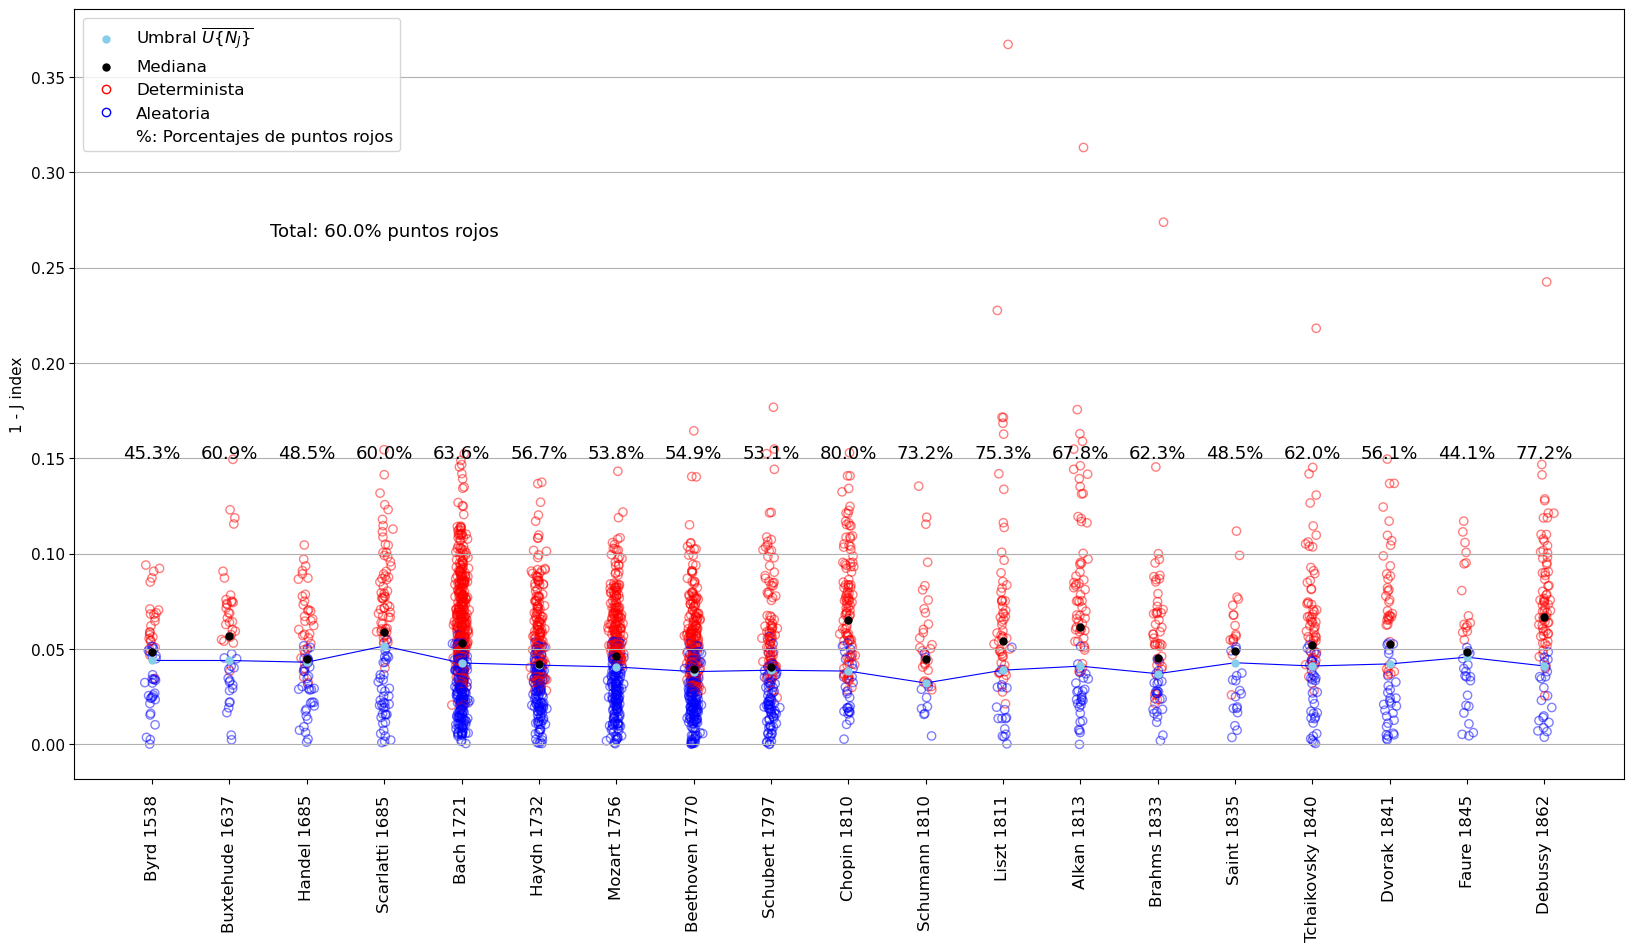

In [7]:
"""Scatter J"""

import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
from matplotlib.lines import Line2D

num_compositores = 19
Ns = np.load('data/Ns_depurado.npy')
J_minus = np.load('data\J_minus_continuo.npy')
print(np.shape(J_minus))

pts_interp = 2
carpeta2 = 'data/J_lineal_sincorte_depurado/interp_'+str(pts_interp)
# carpeta2 = 'data/J_hermite_sincorte_depurado/interp_'+str(pts_interp) 

archivos_en_carpeta2 = os.listdir(carpeta2)

data2 = [1 - np.sort(np.load(os.path.join(carpeta2, array)))[:] for array in archivos_en_carpeta2]
Ns_data = [Ns[array] for array in range(np.shape(Ns)[0])]
J_OG = [1-np.load('data\J_composers_Hz_depurado.npy')[array] for array in range(np.shape(Ns)[0])]

data2 = [array[~np.isnan(array)] for array in data2]
Ns_data = [array[~np.isnan(array)] for array in Ns_data]
J_OG = [array[~np.isnan(array)] for array in J_OG]

for j in range(num_compositores):
    for i in range(len(Ns_data[j])):
        Ns_data[j][i] = (Ns_data[j][i] - 1)*pts_interp + Ns_data[j][i]
        if Ns_data[j][i]//2 >= 13920:
            Ns_data[j][i] = 27840

umbral = [[1-J_minus[1, np.where(J_minus[0] == i//2)[0]][0] for i in Ns_data[j]] for j in range(num_compositores)]
# Aquí, asume que `puntos` es la lista con los num_compositores elementos
# puntos1 = [J_minus[int(np.mean(Ns_data[j])) - 20] for j in range(num_compositores)]
puntos2 = [1-np.mean(np.array([J_minus[1, np.where(J_minus[0] == i//2)[0]] for i in Ns_data[j]])) for j in range(num_compositores)]
mediana = [np.median(array) for array in data2]
print('mean',np.mean(puntos2))
fig, ax = plt.subplots(figsize=(20, 10))
# box2 = ax.boxplot(data2, patch_artist=True)

total_red_points = 0
total_points = 0
porcentajes = []
for i, (d, u) in enumerate(zip(data2, umbral)):
    # Añadir dispersión para evitar superposición
    x = np.random.normal(i + 1, 0.04, size=len(d))
    colors = ['blue' if d_val < u_val else 'red' for d_val, u_val in zip(d, [x for x in u])]
    plt.scatter(x, d, alpha=0.5, color='none', edgecolors=colors)
    # Calcular porcentaje de puntos rojos
    num_red = sum(c == 'red' for c in colors)
    total_points += len(d)
    total_red_points += num_red
    percentage_red = (num_red / len(d)) * 100
    porcentajes.append(percentage_red)
    # Calcular la posición del texto sin exceder el margen superior
    y_text = min(max(d) + 0.05, ax.get_ylim()[1] - 0.05)  # Limitar la posición de texto al margen superior
    
    # Añadir texto con el porcentaje
    ax.text(i + 1, 0.15, f'{percentage_red:.1f}%', ha='center', fontsize=13, color='black')

# np.save('porcentajes_run_avg_50.npy', np.array(porcentajes))
total_percentage_red = (total_red_points / total_points) * 100

# Añadir texto con el porcentaje total
ax.text(0.2, 0.7, f'Total: {total_percentage_red:.1f}% puntos rojos', 
        ha='center', va='bottom', fontsize=13, transform=ax.transAxes, color='black')


# ax.set_xlabel(f'Distribución del índice (1-J) con interpolación lineal de {pts_interp} pts', fontsize=13)
# ax.set_xlabel(f'Distribución del índice (1-J) de las melodias de larga duración', fontsize=13)
ax.set_ylabel('1 - J index', fontsize=11)
ax.tick_params(axis='y', labelsize=11)
ax.set_xticks(np.arange(1, num_compositores+1))

# ax.scatter(np.arange(1, 78), puntos1, color='red', s=50, zorder=3, marker = '*', label=r'$U\{\overline{N_J}\}$')
ax.scatter(np.arange(1, num_compositores+1), puntos2, color='#87CEEB', s=25, zorder=3, marker = 'o', label=r'Umbral $\overline{U\{ N_J \}}$')
# ax.axhline(y=0.029071461469613136)
ax.scatter(np.arange(1, num_compositores+1), mediana, color='black',s=25,zorder=3,marker='o',label='Mediana')
ax.plot(np.arange(1, num_compositores+1), puntos2, color='blue', linestyle='-', linewidth=0.8)
# ax.plot(np.arange(1, 18), mediana, color='red', linestyle='-', linewidth=0.8)
ax.plot([],[], marker = 'o',color='none', markeredgecolor='red', label = 'Determinista')
ax.plot([],[], marker='o', color='none', markeredgecolor='blue', label= 'Aleatoria')
ax.plot([],[], marker='none', color='none', label = '%: Porcentajes de puntos rojos')

# Agregar la leyenda al gráfico
# ax.legend(handles=legend_elements)
ax.legend(loc='upper left',fontsize=12)
# ax.xaxis.set_label_position('top')  # Movemos la etiqueta del eje x
# ax.xaxis.tick_top()  # Movemos los ticks del eje x a la parte superior
# ax.spines['top'].set_position(('axes', 1.0))  # Movemos la espina superior al tope de la figura
# ax.spines['bottom'].set_position(('axes', -0.1))  # Ocultamos la espina inferior
ax.set_xticklabels([f"{composer} {datos_composers[composer]['Birth_year']} " for i, composer in enumerate(datos_composers.keys())], rotation=90,fontsize=12)
plt.grid(axis='y')
plt.show()

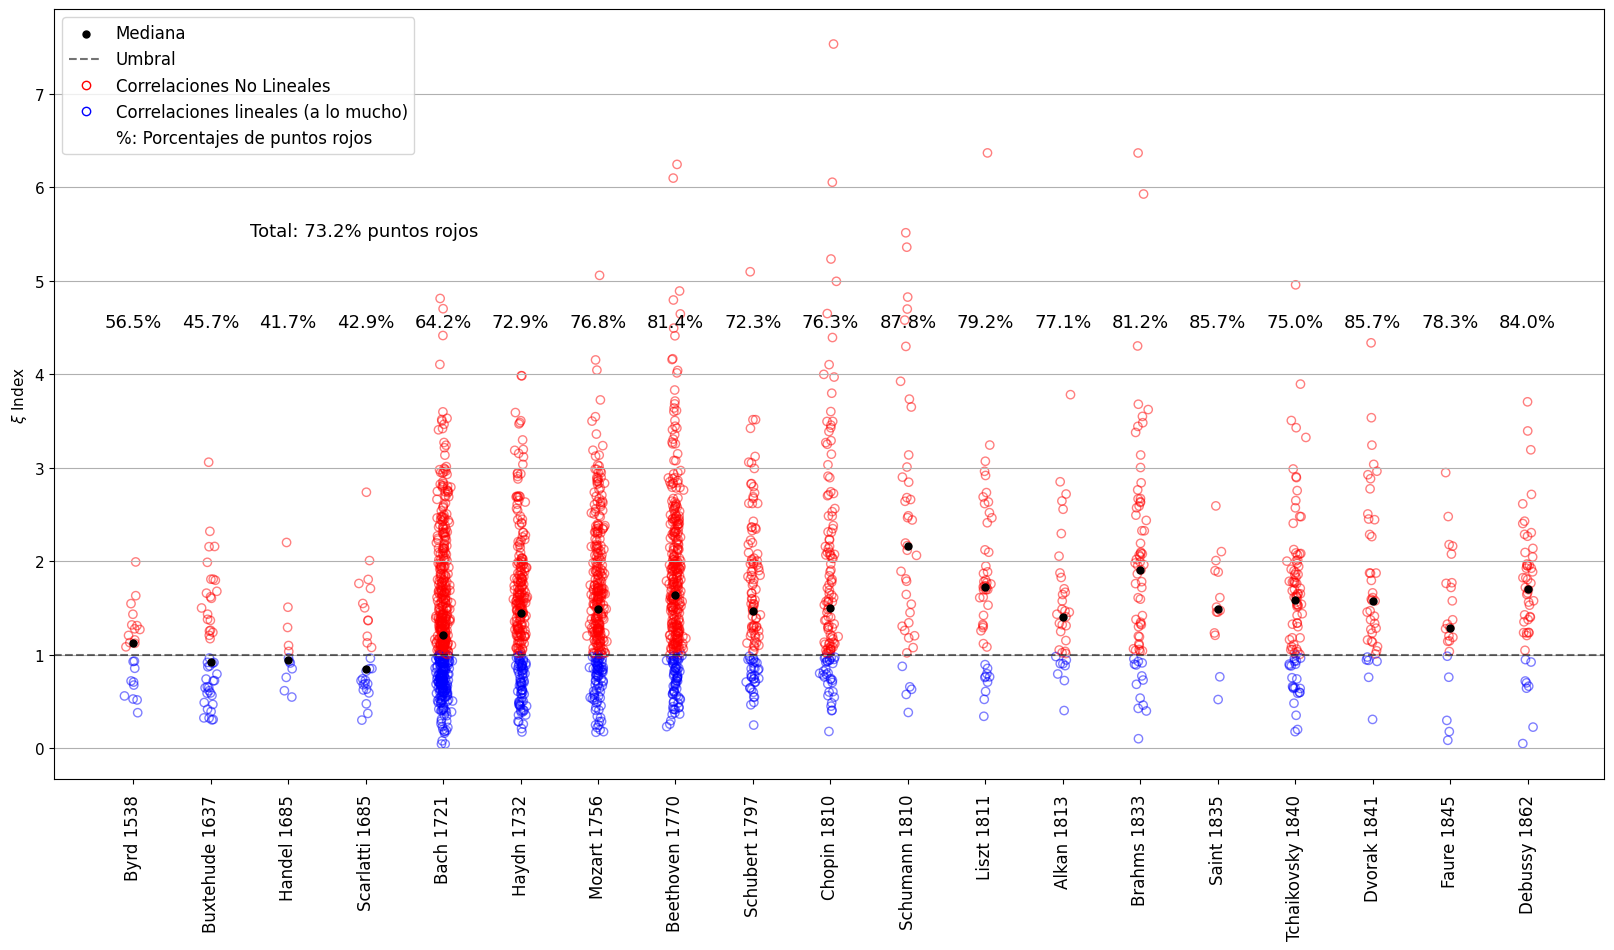

In [ ]:
"""Scatter xi"""

import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.lines import Line2D

xi_index = []
carpeta = r'data/xi_index1'
archivos_en_carpeta = os.listdir(carpeta)
for archivo in archivos_en_carpeta:
    if "xi" in archivo:
        ruta_completa = os.path.join(carpeta, archivo)
        array = np.load(ruta_completa)
        for composer in composers.keys():
            if composer in archivo:
                # print(composer.lower())
                array = array[np.argsort(array[:, 0])]
                array[:,0] -= array[0,0] - 1
                indices = [float(serie.split('_')[1]) for serie in composers[composer].keys()]
                array = array[np.isin(array[:, 0], indices)]
                xi_index.append(array[:,1]-0.2)


# Aquí, asume que `puntos` es la lista con los num_compositores elementos
median = [np.median(array) for array in xi_index]

fig, ax = plt.subplots(figsize=(20, 10))

total_red_points = 0
total_points = 0
porcentajes = []
for i, d in enumerate(xi_index):
    u = [1.0]*len(d)
    # Añadir dispersión para evitar superposición
    x = np.random.normal(i + 1, 0.04, size=len(d))
    colors = ['blue' if d_val < u_val else 'red' for d_val, u_val in zip(d, [x for x in u])]
    plt.scatter(x, d, alpha=0.5, color='none', edgecolors=colors)
    # Calcular porcentaje de puntos rojos
    num_red = sum(c == 'red' for c in colors)
    total_points += len(d)
    total_red_points += num_red
    percentage_red = (num_red / len(d)) * 100
    porcentajes.append(percentage_red)
    # Calcular la posición del texto sin exceder el margen superior
    y_text = min(max(d) + 0.05, ax.get_ylim()[1] - 0.05)  # Limitar la posición de texto al margen superior
    
    # Añadir texto con el porcentaje
    ax.text(i + 1, 4.5, f'{percentage_red:.1f}%', ha='center', fontsize=13, color='black')

# np.save('porcentajes_xi_index.npy', porcentajes)
total_percentage_red = (total_red_points / total_points) * 100

# Añadir texto con el porcentaje total
ax.text(0.2, 0.7, f'Total: {total_percentage_red:.1f}% puntos rojos', 
        ha='center', va='bottom', fontsize=13, transform=ax.transAxes, color='black')


# ax.set_xlabel(r'Distribución del índice de no linealidad $\xi$ de las melodias', fontsize=13)
ax.set_ylabel(r'$\xi$ Index', fontsize = 11)
ax.tick_params(axis='y', labelsize=11)
ax.set_xticks(np.arange(1, 19+1))

# ax.scatter(np.arange(1, 78), puntos1, color='red', s=50, zorder=3, marker = '*', label=r'$U\{\overline{N_J}\}$')
ax.scatter(np.arange(1, 19+1), median, color='black',s=25,zorder=3,marker='o',label='Mediana')
ax.axhline(y=1.0, color='black', linestyle='--', alpha =0.55, label = 'Umbral')
# ax.plot(np.arange(1, 18), mediana, color='red', linestyle='-', linewidth=0.8)
ax.plot([],[], marker = 'o',color='none', markeredgecolor='red', label = 'Correlaciones No Lineales')
ax.plot([],[], marker='o', color='none', markeredgecolor='blue', label= 'Correlaciones lineales (a lo mucho)')
ax.plot([],[], marker='none', color='none', label = '%: Porcentajes de puntos rojos')

# Agregar la leyenda al gráfico
# ax.legend(handles=legend_elements)
ax.legend(loc='upper left', fontsize = 12)
# ax.xaxis.set_label_position('top')  # Movemos la etiqueta del eje x
# ax.xaxis.tick_top()  # Movemos los ticks del eje x a la parte superior
# ax.spines['top'].set_position(('axes', 1.0))  # Movemos la espina superior al tope de la figura
# ax.spines['bottom'].set_position(('axes', -0.1))  # Ocultamos la espina inferior
ax.set_xticklabels([f"{composer} {datos_composers_depurado_v2[composer]['Birth_year']} " for i, composer in enumerate(list(datos_composers_depurado_v2.keys()))], rotation=90, fontsize = 12)


plt.grid(axis='y')
plt.show()